In [1]:
import os
import re
import glob
from pathlib import Path
from datetime import datetime
from scipy.interpolate import interp1d
import geopandas as gpd
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import rasterio
from rasterio.mask import mask as rio_mask
from rasterio.warp import Resampling, reproject

repo_root = Path.cwd().resolve()
if not (repo_root / 'src').exists():
    repo_root = repo_root.parent

# --- configuration ---
SR_ZONE_ROUTING = {
    "zone_1_peuplier": {
        "sen2srlite": Path(r"C:\Users\ahtrabelsi\Desktop\results\patch_zone_1_peuplier_000_sen2srlite (1)\sr"),
        "sen2sr": Path(r"C:\Users\ahtrabelsi\Desktop\results\patch_zone_1_peuplier_000_sen2sr\sr"),
    },
    "zone_2_betterave": {
        "sen2srlite": Path(r"C:\Users\ahtrabelsi\Downloads\patch_zone_2_betterave_001_sen2srlite (1)\sr"),
        "sen2sr": Path(r"C:\Users\ahtrabelsi\Downloads\patch_zone_2_betterave_001_sen2sr\sr"),
        "ldsr": Path(r"C:\Users\ahtrabelsi\Downloads\patch_zone_2_betterave_001_ldsr\sr"),
    },
    "zone_3_betterave": {
        "sen2srlite": Path(r"C:\Users\ahtrabelsi\Desktop\results\patch_zone_3_betterave_002_sen2srlite (1)\sr"),
        "sen2sr": Path(r"C:\Users\ahtrabelsi\Desktop\results\patch_zone_3_betterave_002_sen2sr (1)\sr"),
        "ldsr": Path(r"C:\Users\ahtrabelsi\Desktop\results\patch_zone_3_betterave_002_ldsr"),
    },
    "zone_4_betterave": {
        "sen2srlite": Path(r"C:\Users\ahtrabelsi\Desktop\results\patch_zone_4_betterave_003_sen2srlite (1)\sr"),
        "sen2sr": Path(r"C:\Users\ahtrabelsi\Desktop\results\patch_zone_4_betterave_003_sen2sr (1)\sr"),
        "ldsr": Path(r"C:\Users\ahtrabelsi\Desktop\results\patch_zone_4_betterave_003_ldsr\sr"),
    },
}

GLOBAL_PS_DIR = Path(r"C:\Users\ahtrabelsi\Desktop\stage\s2-super-resolution\data\beetsat_psscene_analytic_sr_udm2\PSScene")
ZONE_PATHS = {
    'zone_1_peuplier': Path(repo_root / 'data' / 'zones' / 'zone_1_peuplier.gpkg'),
    'zone_2_betterave': Path(repo_root / 'data' / 'zones' / 'zone_2_betterave.gpkg'),
    'zone_3_betterave': Path(repo_root / 'data' / 'zones' / 'zone_3_betterave.gpkg'),
    'zone_4_betterave': Path(repo_root / 'data' / 'zones' / 'zone_4_betterave.gpkg'),
}

S2_DATES_FILE = Path(r"C:\Users\ahtrabelsi\Desktop\stage\s2-super-resolution\data\Sentinel2_T31UEQ_interpolation_dates.txt")
S2_STACK_PATH = Path("C:/Users/ahtrabelsi/Desktop/stage/S2 data/Sentinel2_T31UEQ_TSG.tif")
S2_TO_PS_IDX = {
    'sen2srlite': [0, 1, 2, 7],
    'sen2sr': [0, 1, 2, 7],
    'ldsr': [0, 1, 2, 3],
}

COVERAGE_THRESHOLD = 0.9
PS_BANDS = [1, 2, 3, 4]
RGB_IDX = [2, 1, 0]
ACTIVE_ZONE = 'zone_2_betterave'
OUTPUT_DIR = repo_root / 'outputs' / 'evaluation'
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

In [2]:
import lpips
import torch
from skimage.metrics import peak_signal_noise_ratio as psnr_fn
from skimage.metrics import structural_similarity as _ssim_full

# ──────────────────────────────────────────────────────────────
# PS / SR DATE PATTERN
# ──────────────────────────────────────────────────────────────
DATE_RE = re.compile(r'(\d{4}-\d{2}-\d{2})|(\d{8})')  # match YYYY-MM-DD or YYYYMMDD

# ──────────────────────────────────────────────────────────────
# PS FILE DISCOVERY
# ──────────────────────────────────────────────

def find_ps_files(ps_dir: Path):
    ps_dir = Path(ps_dir)
    candidates = ps_dir.rglob('*.tif')
    valid_paths = []
    for p in candidates:
        name_lower = p.name.lower()
        if 'udm' in name_lower or 'xml' in name_lower or 'metadata' in name_lower:
            continue
        if 'analyticms_sr' in name_lower:
            valid_paths.append(p)
    return sorted(valid_paths)


def extract_date_from_path(path: Path):
    m = DATE_RE.search(path.name)
    if not m:
        return None
    date_str = m.group(1) if m.group(1) else m.group(2)
    try:
        if '-' in date_str:
            return datetime.strptime(date_str, '%Y-%m-%d')
        return datetime.strptime(date_str, '%Y%m%d')
    except ValueError:
        return None


def clip_ps_to_zone(path: Path, zone_gdf: gpd.GeoDataFrame):
    with rasterio.open(path) as src:
        if zone_gdf.crs is None:
            zone_gdf = zone_gdf.set_crs('EPSG:32631')
        zone_proj = zone_gdf.to_crs(src.crs)
        geoms = [g.__geo_interface__ for g in zone_proj.geometry]
        src_nodata = src.nodata if src.nodata is not None else 0
        try:
            arr, transform = rio_mask(
                src,
                geoms,
                crop=True,
                indexes=PS_BANDS,
                filled=True,
                nodata=src_nodata,
            )
        except ValueError:
            return None, None
        arr = arr.astype(np.float32)
        arr[arr == src_nodata] = np.nan
        profile = src.profile.copy()
        profile.update(
            transform=transform,
            height=arr.shape[1],
            width=arr.shape[2],
            count=arr.shape[0],
            dtype='float32',
        )
    return arr, profile


def coverage_fraction(arr: np.ndarray):
    valid = ~np.isnan(arr).any(axis=0)
    return float(valid.sum()) / valid.size


# ──────────────────────────────────────────────────────────────
# S2 DATES
# ──────────────────────────────────────────────────────────────

def load_s2_dates(path: Path):
    dates = []
    with open(path, 'r') as f:
        for line in f:
            line = line.strip()
            if not line:
                continue
            dates.append(datetime.strptime(line, '%Y%m%d'))
    return dates


# ──────────────────────────────────────────────────────────────
# SR FILE DISCOVERY
# ──────────────────────────────────────────────

def find_sr_files(sr_dir: Path):
    sr_dir = Path(sr_dir)
    if not sr_dir.exists():
        return []
    files = []
    for path in sr_dir.rglob('*'):
        if path.suffix.lower() in ('.tif', '.tiff'):
            files.append(path)
    return sorted(files)


def extract_date_from_sr(path: Path):
    m = DATE_RE.search(path.name)
    if not m:
        return None
    date_str = m.group(1) if m.group(1) else m.group(2)
    try:
        if '-' in date_str:
            return datetime.strptime(date_str, '%Y-%m-%d')
        return datetime.strptime(date_str, '%Y%m%d')
    except ValueError:
        return None


def debug_sr_date_parsing(sr_dir: Path):
    print(f"Debug SR directory: {sr_dir}")
    sr_files = find_sr_files(sr_dir)
    print(f"  found {len(sr_files)} TIFF files")
    for path in sr_files[:20]:
        parsed = extract_date_from_sr(path)
        print(f"   {path.name} -> {parsed}")
    return sr_files


# ──────────────────────────────────────────────────────────────
# SR → PS GRID ALIGNMENT
# ──────────────────────────────────────────────────────────────

def warp_sr_to_ps(sr_path: Path, ps_profile: dict):
    with rasterio.open(sr_path) as src:
        n_bands = src.count
        src_nodata = src.nodata
        dst = np.full((n_bands, ps_profile['height'], ps_profile['width']), np.nan, dtype=np.float32)
        for b in range(1, n_bands + 1):
            band = np.array(src.read(b), dtype=np.float32, copy=True)
            if src_nodata is not None:
                band[band == src_nodata] = np.nan
            reproject(
                source=band,
                destination=dst[b - 1],
                src_transform=src.transform,
                src_crs=src.crs,
                dst_transform=ps_profile['transform'],
                dst_crs=ps_profile['crs'],
                resampling=Resampling.bilinear,
                src_nodata=np.nan,
                dst_nodata=np.nan,
            )
    return dst


def extract_sr_bands(sr_warped: np.ndarray, model_name: str):
    idx = S2_TO_PS_IDX[model_name]
    return sr_warped[idx]


# ──────────────────────────────────────────────────────────────
# ALIGNMENT / MASKING
# ──────────────────────────────────────────────────────────────

def align_arrays(arr1: np.ndarray, arr2: np.ndarray):
    h = min(arr1.shape[1], arr2.shape[1])
    w = min(arr1.shape[2], arr2.shape[2])
    def center_crop(a, h, w):
        H, W = a.shape[1], a.shape[2]
        top = (H - h) // 2
        left = (W - w) // 2
        return a[:, top:top + h, left:left + w]
    return center_crop(arr1, h, w), center_crop(arr2, h, w)


def shared_valid_mask(arr1: np.ndarray, arr2: np.ndarray):
    return ~(np.isnan(arr1).any(axis=0) | np.isnan(arr2).any(axis=0))


# ──────────────────────────────────────────────────────────────
# METRIC HELPERS
# ──────────────────────────────────────────────────────────────

def ssim_fn(im1: np.ndarray, im2: np.ndarray, data_range: float = 1.0, mask: np.ndarray = None):
    if mask is None:
        return float(_ssim_full(im1, im2, data_range=data_range))
    _, smap = _ssim_full(im1, im2, data_range=data_range, full=True)
    return float(smap[mask].mean())


# LPIPS model, instantiate once
loss_fn_lpips = lpips.LPIPS(net='alex')
loss_fn_lpips.eval()


Setting up [LPIPS] perceptual loss: trunk [alex], v[0.1], spatial [off]


c:\Users\ahtrabelsi\Desktop\stage\s2-super-resolution\.venv\Lib\site-packages\torchvision\models\_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
c:\Users\ahtrabelsi\Desktop\stage\s2-super-resolution\.venv\Lib\site-packages\torchvision\models\_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=AlexNet_Weights.IMAGENET1K_V1`. You can also use `weights=AlexNet_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


Loading model from: c:\Users\ahtrabelsi\Desktop\stage\s2-super-resolution\.venv\Lib\site-packages\lpips\weights\v0.1\alex.pth


LPIPS(
  (scaling_layer): ScalingLayer()
  (net): alexnet(
    (slice1): Sequential(
      (0): Conv2d(3, 64, kernel_size=(11, 11), stride=(4, 4), padding=(2, 2))
      (1): ReLU(inplace=True)
    )
    (slice2): Sequential(
      (2): MaxPool2d(kernel_size=3, stride=2, padding=0, dilation=1, ceil_mode=False)
      (3): Conv2d(64, 192, kernel_size=(5, 5), stride=(1, 1), padding=(2, 2))
      (4): ReLU(inplace=True)
    )
    (slice3): Sequential(
      (5): MaxPool2d(kernel_size=3, stride=2, padding=0, dilation=1, ceil_mode=False)
      (6): Conv2d(192, 384, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
      (7): ReLU(inplace=True)
    )
    (slice4): Sequential(
      (8): Conv2d(384, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
      (9): ReLU(inplace=True)
    )
    (slice5): Sequential(
      (10): Conv2d(256, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
      (11): ReLU(inplace=True)
    )
  )
  (lin0): NetLinLayer(
    (model): Sequential(
      (0): D

# Unified evaluation notebook

This notebook consolidates the previous evaluation workflows into a single pipeline for comparing super-resolution outputs against PlanetScope references.

The pipeline includes:
1. Discovering PlanetScope reference scenes.
2. Screening scenes by spatial coverage inside the target zone.
3. Pairing SR outputs with the closest valid PlanetScope reference.
4. Aligning SR outputs to the reference grid.
5. Computing metrics and exporting summaries.
6. Including a baseline based on bicubic interpolation of the LR Sentinel-2 image to 2.5 m.

In [3]:
# ──────────────────────────────────────────────────────────────
# SCREEN SCENES (CORRECTED)
# ──────────────────────────────────────────────────────────────

def screen_ps_scenes(zone_name: str, ps_dir: Path, zone_paths: dict, threshold: float = COVERAGE_THRESHOLD):
    zone_gdf = gpd.read_file(zone_paths[zone_name])
    
    # Force zone coordinate system check without losing native metadata
    if zone_gdf.crs is None:
        # Fallback to local UTM zone 31N (S2 default for your region)
        zone_gdf = zone_gdf.set_crs("EPSG:32631")
    
    ps_files = find_ps_files(ps_dir)
    print(len(ps_files))
    if not ps_files:
        print(f"[WARNING] No PS files found in directory: {ps_dir}")
        return []

    passed = []
    overlap_failures = 0
    
    for path in ps_files:
        date = extract_date_from_path(path)
        if date is None:
            continue
            
        # Clip directly using target raster CRS (avoids double projection errors)
        arr, profile = clip_ps_to_zone(path, zone_gdf)
        if arr is None or profile is None:
            overlap_failures += 1
            continue
            
        cov = coverage_fraction(arr)
        if cov >= threshold:
            passed.append({
                'path': path, 
                'date': date, 
                'array': arr, 
                'profile': profile, 
                'coverage': cov
            })

    print(f"[DEBUG] Processing complete. {len(passed)} passed threshold, {overlap_failures} had no spatial overlap.")
    
    # Sort and filter to keep only one reference per month (highest coverage)
    passed.sort(key=lambda item: (-item['coverage'], item['date']))
    
    unique_months = {}
    for item in passed:
        month_key = (item['date'].year, item['date'].month)
        if month_key not in unique_months:
            unique_months[month_key] = item
            
    passed = list(unique_months.values())
    passed.sort(key=lambda item: item['date'])
    
    print(f'[{zone_name}] {len(passed)} scenes passed coverage >= {threshold:.0%}')
    return passed


valid_ps = screen_ps_scenes(ACTIVE_ZONE, GLOBAL_PS_DIR, ZONE_PATHS)

19
[DEBUG] Processing complete. 10 passed threshold, 1 had no spatial overlap.
[zone_2_betterave] 9 scenes passed coverage >= 90%


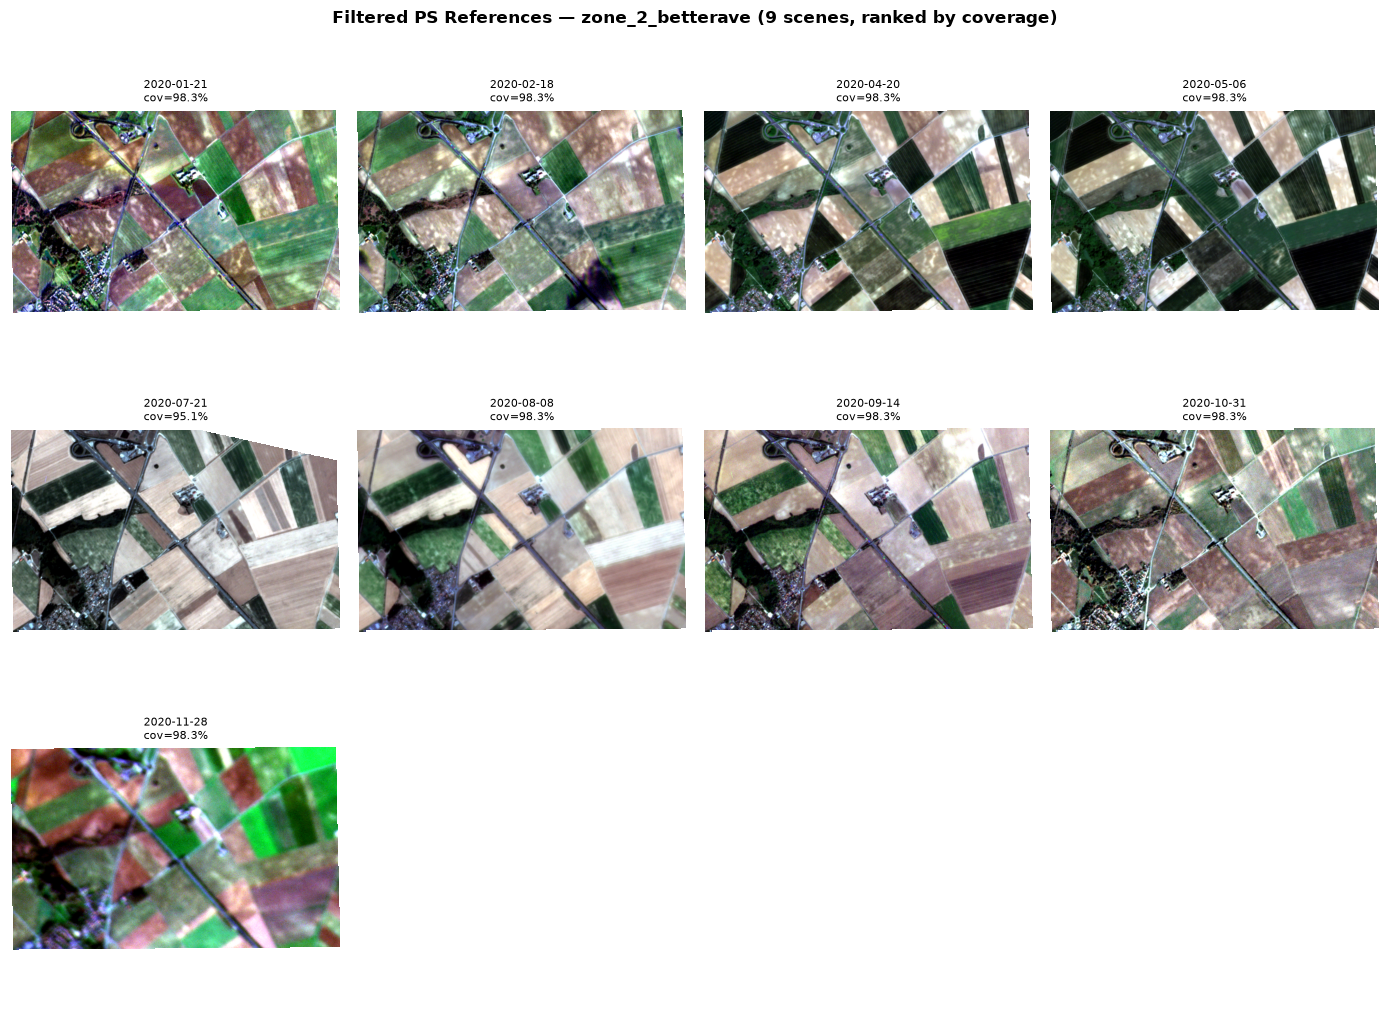

In [4]:
def to_rgb(array: np.ndarray, rgb_idx=RGB_IDX, percentile: float = 2.0):
    rgb = array[rgb_idx]
    out = np.zeros((rgb.shape[1], rgb.shape[2], 3), dtype=np.float32)
    for i in range(3):
        band = rgb[i]
        lo = np.nanpercentile(band, percentile)
        hi = np.nanpercentile(band, 100 - percentile)
        out[..., i] = np.clip((band - lo) / (hi - lo + 1e-9), 0, 1)
    return out

def plot_filtered_ps(valid_ps, zone_name: str, max_cols: int = 4):
    n = len(valid_ps)
    if n == 0:
        print('No valid scenes to display.')
        return

    cols = min(n, max_cols)
    rows = (n + cols - 1) // cols
    fig, axes = plt.subplots(rows, cols, figsize=(cols * 3.5, rows * 3.5))
    axes = np.atleast_1d(axes).flatten()

    for i, scene in enumerate(valid_ps):
        axes[i].imshow(to_rgb(scene['array']))
        axes[i].set_title(f"{scene['date'].strftime('%Y-%m-%d')}\ncov={scene['coverage']:.1%}", fontsize=8)
        axes[i].axis('off')

    for j in range(i + 1, len(axes)):
        axes[j].axis('off')

    fig.suptitle(f'Filtered PS References — {zone_name} ({n} scenes, ranked by coverage)', fontsize=12, fontweight='bold')
    plt.tight_layout()
    # plt.savefig(OUTPUT_DIR / 'coverage_screening_gallery.png', dpi=150, bbox_inches='tight')
    plt.show()

plot_filtered_ps(valid_ps, ACTIVE_ZONE)

In [5]:
def match_histograms_bandwise(src_arr: np.ndarray, ref_arr: np.ndarray):
    out = np.full_like(src_arr, np.nan, dtype=np.float32)
    for b in range(src_arr.shape[0]):
        src_2d = src_arr[b]
        ref_2d = ref_arr[b]
        
        # Match using all non-NaN values of each image individually (entire image, not parcel specific)
        src_valid = src_2d[~np.isnan(src_2d)].ravel()
        ref_valid = ref_2d[~np.isnan(ref_2d)].ravel()
        if src_valid.size < 100 or ref_valid.size < 100:
            out[b] = src_2d
            continue

        src_sorted = np.sort(src_valid)
        ref_sorted = np.sort(ref_valid)
        n = min(len(src_sorted), len(ref_sorted))
        quantiles = np.linspace(0, 1, n)
        src_q = np.interp(quantiles, np.linspace(0, 1, len(src_sorted)), src_sorted)
        ref_q = np.interp(quantiles, np.linspace(0, 1, len(ref_sorted)), ref_sorted)

        interp_fn = interp1d(
            src_q,
            ref_q,
            bounds_error=False,
            fill_value=(ref_q[0], ref_q[-1]),
        )
        corrected = src_2d.copy()
        band_valid = ~np.isnan(src_2d)
        corrected[band_valid] = interp_fn(src_2d[band_valid])
        out[b] = corrected
    return out


In [6]:
S2_DATES = load_s2_dates(S2_DATES_FILE)

def extract_s2_image(stack_path: Path, zone_path: Path, target_date: datetime):
    """
    Extract the Sentinel-2 image nearest to target_date and clip it
    to the zone polygon from the .gpkg.

    Returns
    -------
    img : ndarray (10,H,W) float32
    profile : raster profile
    matched_date : datetime
    """

    # Find nearest acquisition
    idx = np.argmin([abs((d - target_date).days) for d in S2_DATES])

    start = idx * 10 + 1
    stop = start + 10

    zone_gdf = gpd.read_file(zone_path)

    with rasterio.open(stack_path) as src:
        zone_proj = zone_gdf.to_crs(src.crs)
        geoms = [g.__geo_interface__ for g in zone_proj.geometry]
        
        # Use source nodata or 0 for integer rasters
        src_nodata = src.nodata if src.nodata is not None else 0
        
        # Clip with source-compatible nodata
        img, transform = rio_mask(
            src,
            geoms,
            crop=True,
            indexes=range(start, stop),
            filled=True,
            nodata=src_nodata,
        )

        # Convert to float and replace nodata with NaN
        img = img.astype(np.float32)
        img[img == src_nodata] = np.nan

        profile = src.profile.copy()
        profile.update(
            transform=transform,
            height=img.shape[1],
            width=img.shape[2],
            count=img.shape[0],
            dtype='float32',
        )

    return img, profile, S2_DATES[idx]


def build_baseline_from_stack(
    stack_path: Path,
    zone_path: Path,
    target_date: datetime,
    ps_profile: dict,
    model_name: str,
):

    s2_img, s2_profile, matched_date = extract_s2_image(
        stack_path,
        zone_path,
        target_date,
    )

    s2_img = s2_img[S2_TO_PS_IDX[model_name]]

    baseline = np.full(
        (4,
         ps_profile["height"],
         ps_profile["width"]),
        np.nan,
        dtype=np.float32,
    )

    for b in range(4):

        reproject(
            source=s2_img[b],
            destination=baseline[b],
            src_transform=s2_profile["transform"],
            src_crs=s2_profile["crs"],
            dst_transform=ps_profile["transform"],
            dst_crs=ps_profile["crs"],
            resampling=Resampling.bilinear,
            src_nodata=np.nan,
            dst_nodata=np.nan,
        )

    return baseline, matched_date

In [7]:
def compute_sam(arr1: np.ndarray, arr2: np.ndarray, mask2d: np.ndarray):
    a = arr1[:, mask2d].T
    b = arr2[:, mask2d].T
    dot = np.sum(a * b, axis=1)
    norm = np.linalg.norm(a, axis=1) * np.linalg.norm(b, axis=1) + 1e-9
    return float(np.degrees(np.arccos(np.clip(dot / norm, -1, 1))).mean())

def to_lpips_tensor(arr_rgb_hw3: np.ndarray):
    arr = np.nan_to_num(arr_rgb_hw3, nan=0.0, posinf=1.0, neginf=0.0).astype(np.float32)
    t = torch.from_numpy(arr).permute(2, 0, 1).unsqueeze(0)
    lo, hi = t.min(), t.max()
    if torch.isclose(hi, lo):
        return torch.full_like(t, -1.0)
    return (t - lo) / (hi - lo) * 2 - 1

def compute_metrics(ps_arr: np.ndarray, sr_arr: np.ndarray, mask2d: np.ndarray = None):
    # Force mask to be full-image validity only (NaN/nodata exclusion),
    # never a parcel- or polygon-restricted subset.
    mask2d = ~(np.isnan(ps_arr).any(axis=0) | np.isnan(sr_arr).any(axis=0))

    if mask2d.sum() < 100:
        res = {m: np.nan for m in ['PSNR', 'SSIM', 'RMSE', 'SAM', 'LPIPS']}
        for band_name in ['B2', 'B3', 'B4', 'B8']:
            res[f'PSNR_{band_name}'] = np.nan
            res[f'SSIM_{band_name}'] = np.nan
        return res

    ps_m = ps_arr[:, mask2d]
    sr_m = sr_arr[:, mask2d]
    lo = np.nanmin(ps_m)
    hi = np.nanmax(ps_m)
    ps_n = (ps_arr - lo) / (hi - lo + 1e-9)
    sr_n = (sr_arr - lo) / (hi - lo + 1e-9)

    psnr_vals, ssim_vals = [], []
    for b in range(ps_arr.shape[0]):
        pb = ps_n[b].copy()
        sb = sr_n[b].copy()
        pb[~mask2d] = 0
        sb[~mask2d] = 0
        psnr_vals.append(psnr_fn(pb, sb, data_range=1.0))
        ssim_vals.append(ssim_fn(pb, sb, data_range=1.0, mask=mask2d))

    rmse = np.sqrt(np.mean((ps_m - sr_m) ** 2))
    sam = compute_sam(ps_arr, sr_arr, mask2d)

    ps_rgb = to_rgb(ps_arr)
    sr_rgb = to_rgb(sr_arr)
    with torch.no_grad():
        lp = loss_fn_lpips(to_lpips_tensor(ps_rgb), to_lpips_tensor(sr_rgb)).item()

    res = {
        'PSNR': float(np.mean(psnr_vals)),
        'SSIM': float(np.mean(ssim_vals)),
        'RMSE': float(rmse),
        'SAM': float(sam),
        'LPIPS': float(lp),
    }
    band_names = ['B2', 'B3', 'B4', 'B8']
    for idx, band_name in enumerate(band_names):
        res[f'PSNR_{band_name}'] = float(psnr_vals[idx])
        res[f'SSIM_{band_name}'] = float(ssim_vals[idx])
    return res

# STEP 1: VERIFICATION PIPELINE
Test on single zone before running full evaluation (zone_2_betterave)

In [8]:
def run_zone_evaluation(zone_name: str, ps_scenes: list[dict]):
    """
    Run complete evaluation for one zone following exact evaluation2 pipeline:
    1. Pair PS reference with closest SR per model (monthly)
    2. Geometric alignment & center-crop to common dimensions
    3. Histogram matching bandwise (radiometric equalization)
    4. Compute metrics (PSNR, SSIM, RMSE, SAM, LPIPS)
    5. Include bicubic baseline from S2 stack
    """
    all_rows = []
    evaluated_baselines = set()

    # Determine available models for this zone
    available_models = list(SR_ZONE_ROUTING[zone_name].keys())
    
    for model_name in available_models:
        print(f"\n{'='*60}")
        print(f"Evaluating {zone_name} / {model_name}")
        print(f"{'='*60}")
        
        sr_dir = SR_ZONE_ROUTING[zone_name][model_name]
        sr_files = find_sr_files(sr_dir)
        
        if not sr_files:
            print(f"  No SR files found in {sr_dir}")
            continue

        # For each PS reference, find closest SR file (monthly pairing with smaller delta days)
        for ref_scene in ps_scenes:
            ref_date = ref_scene['date']
            
            # Find candidate SR files from same month and year
            candidate_srs = []
            for sr_path in sr_files:
                sr_date = extract_date_from_sr(sr_path)
                if sr_date is not None and sr_date.month == ref_date.month and sr_date.year == ref_date.year:
                    candidate_srs.append((sr_path, sr_date))
            
            if not candidate_srs:
                continue

            # Pick closest SR file by date
            sr_path, sr_date = min(
                candidate_srs,
                key=lambda x: abs((x[1] - ref_date).days)
            )
            
            ref_ps_array = ref_scene['array']
            delta_days = abs((ref_scene['date'] - sr_date).days)

            # ──────────────────────────────────────────────────────────────
            # STEP 1: Geometric alignment (warp SR to PS grid, center-crop)
            # ──────────────────────────────────────────────────────────────
            sr_warped = warp_sr_to_ps(sr_path, ref_scene['profile'])
            sr_4band = extract_sr_bands(sr_warped, model_name)

            # Center-crop both to common spatial dimensions
            if ref_ps_array.shape[1:] != sr_4band.shape[1:]:
                ref_ps_aligned, sr_4band = align_arrays(ref_ps_array, sr_4band)
            else:
                ref_ps_aligned = ref_ps_array

            # ──────────────────────────────────────────────────────────────
            # STEP 2: Compute valid mask and histogram matching
            # ──────────────────────────────────────────────────────────────
            mask_2d = shared_valid_mask(ref_ps_aligned, sr_4band)
            sr_eq = match_histograms_bandwise(sr_4band, ref_ps_aligned)

            # ──────────────────────────────────────────────────────────────
            # STEP 3: Compute metrics for SR model
            # ──────────────────────────────────────────────────────────────
            metrics = compute_metrics(ref_ps_aligned, sr_eq, mask_2d)
            metrics.update({
                'zone': zone_name,
                'model': model_name,
                'month': ref_scene['date'].strftime('%Y-%m'),
                'ps_date': ref_scene['date'].date(),
                'sr_date': sr_date.date(),
                'delta_days': delta_days,
                'coverage': ref_scene['coverage'],
            })
            all_rows.append(metrics)
            print(f"  {metrics['month']}: PSNR={metrics['PSNR']:.2f} SSIM={metrics['SSIM']:.4f} "
                  f"RMSE={metrics['RMSE']:.4f} SAM={metrics['SAM']:.2f} LPIPS={metrics['LPIPS']:.4f}")

            # ──────────────────────────────────────────────────────────────
            # STEP 4: Bicubic baseline (compute once per reference date)
            # ──────────────────────────────────────────────────────────────
            baseline_key = (zone_name, ref_scene['date'])
            
            if baseline_key not in evaluated_baselines:
                evaluated_baselines.add(baseline_key)
                
                baseline, baseline_date = build_baseline_from_stack(
                    stack_path=S2_STACK_PATH,
                    zone_path=ZONE_PATHS[zone_name],
                    target_date=ref_scene['date'],
                    ps_profile=ref_scene['profile'],
                    model_name=model_name,
                )

                # Align baseline to PS grid
                if ref_ps_array.shape[1:] != baseline.shape[1:]:
                    ref_base_aligned, baseline = align_arrays(ref_ps_array, baseline)
                else:
                    ref_base_aligned = ref_ps_array

                # Histogram matching for baseline
                baseline_mask = shared_valid_mask(ref_base_aligned, baseline)
                baseline_eq = match_histograms_bandwise(baseline, ref_base_aligned)

                # Compute metrics for baseline
                baseline_metrics = compute_metrics(ref_base_aligned, baseline_eq, baseline_mask)
                baseline_metrics.update({
                    'zone': zone_name,
                    'model': 'bicubic_baseline',
                    'month': ref_scene['date'].strftime('%Y-%m'),
                    'ps_date': ref_scene['date'].date(),
                    'sr_date': baseline_date.date(),
                    'delta_days': abs((baseline_date - ref_scene['date']).days),
                    'coverage': ref_scene['coverage'],
                })
                all_rows.append(baseline_metrics)
                print(f"  {baseline_metrics['month']} [BASELINE]: PSNR={baseline_metrics['PSNR']:.2f} SSIM={baseline_metrics['SSIM']:.4f} "
                      f"RMSE={baseline_metrics['RMSE']:.4f} SAM={baseline_metrics['SAM']:.2f} LPIPS={baseline_metrics['LPIPS']:.4f}")

    return pd.DataFrame(all_rows) if all_rows else pd.DataFrame()

In [9]:
all_zone_results = []

for zone_name in ZONE_PATHS:
    print(f"\n{'#'*70}")
    print(f"# ZONE: {zone_name}")
    print(f"{'#'*70}")

    if zone_name not in SR_ZONE_ROUTING:
        print(f"  No SR routing defined for {zone_name}, skipping.")
        continue

    ps_scenes = screen_ps_scenes(zone_name, GLOBAL_PS_DIR, ZONE_PATHS)

    if not ps_scenes:
        print(f"  No valid PS scenes for {zone_name}, skipping.")
        continue

    zone_df = run_zone_evaluation(zone_name, ps_scenes)

    if not zone_df.empty:
        all_zone_results.append(zone_df)
        print(f"\n  ✓ {zone_name}: {len(zone_df)} rows added")
    else:
        print(f"\n  ⚠ {zone_name}: no results produced")

results_df = pd.concat(all_zone_results, ignore_index=True) if all_zone_results else pd.DataFrame()

print(f"\n{'='*70}")
print(f"TOTAL RESULTS: {len(results_df)} rows across {results_df['zone'].nunique() if not results_df.empty else 0} zones")
print(f"{'='*70}")
if not results_df.empty:
    print(results_df.groupby(['zone', 'model']).size())


######################################################################
# ZONE: zone_1_peuplier
######################################################################
19
[DEBUG] Processing complete. 10 passed threshold, 1 had no spatial overlap.
[zone_1_peuplier] 10 scenes passed coverage >= 90%

Evaluating zone_1_peuplier / sen2srlite


C:\Users\ahtrabelsi\AppData\Local\Temp\ipykernel_14116\3238846864.py:140: DeprecationWarning: Setting the shape on a NumPy array has been deprecated in NumPy 2.5.
As an alternative, you can create a new view using np.reshape (with copy=False if needed).
  band = np.array(src.read(b), dtype=np.float32, copy=True)
C:\Users\ahtrabelsi\AppData\Local\Temp\ipykernel_14116\3238846864.py:140: DeprecationWarning: Setting the shape on a NumPy array has been deprecated in NumPy 2.5.
As an alternative, you can create a new view using np.reshape (with copy=False if needed).
  band = np.array(src.read(b), dtype=np.float32, copy=True)
C:\Users\ahtrabelsi\AppData\Local\Temp\ipykernel_14116\3238846864.py:140: DeprecationWarning: Setting the shape on a NumPy array has been deprecated in NumPy 2.5.
As an alternative, you can create a new view using np.reshape (with copy=False if needed).
  band = np.array(src.read(b), dtype=np.float32, copy=True)
C:\Users\ahtrabelsi\AppData\Local\Temp\ipykernel_14116\323

  2020-02: PSNR=34.29 SSIM=0.8230 RMSE=156.9737 SAM=2.00 LPIPS=0.5911
  2020-02 [BASELINE]: PSNR=34.09 SSIM=0.8479 RMSE=133.0898 SAM=1.92 LPIPS=0.5626


C:\Users\ahtrabelsi\AppData\Local\Temp\ipykernel_14116\3238846864.py:140: DeprecationWarning: Setting the shape on a NumPy array has been deprecated in NumPy 2.5.
As an alternative, you can create a new view using np.reshape (with copy=False if needed).
  band = np.array(src.read(b), dtype=np.float32, copy=True)
C:\Users\ahtrabelsi\AppData\Local\Temp\ipykernel_14116\3238846864.py:140: DeprecationWarning: Setting the shape on a NumPy array has been deprecated in NumPy 2.5.
As an alternative, you can create a new view using np.reshape (with copy=False if needed).
  band = np.array(src.read(b), dtype=np.float32, copy=True)
C:\Users\ahtrabelsi\AppData\Local\Temp\ipykernel_14116\3238846864.py:140: DeprecationWarning: Setting the shape on a NumPy array has been deprecated in NumPy 2.5.
As an alternative, you can create a new view using np.reshape (with copy=False if needed).
  band = np.array(src.read(b), dtype=np.float32, copy=True)
C:\Users\ahtrabelsi\AppData\Local\Temp\ipykernel_14116\323

  2020-04: PSNR=38.77 SSIM=0.9330 RMSE=130.6307 SAM=1.47 LPIPS=0.3695
  2020-04 [BASELINE]: PSNR=38.63 SSIM=0.9064 RMSE=122.4440 SAM=1.37 LPIPS=0.2972


...

  2020-09: PSNR=37.52 SSIM=0.9155 RMSE=103.7347 SAM=1.50 LPIPS=0.4888


C:\Users\ahtrabelsi\AppData\Local\Temp\ipykernel_14116\3238846864.py:140: DeprecationWarning: Setting the shape on a NumPy array has been deprecated in NumPy 2.5.
As an alternative, you can create a new view using np.reshape (with copy=False if needed).
  band = np.array(src.read(b), dtype=np.float32, copy=True)
C:\Users\ahtrabelsi\AppData\Local\Temp\ipykernel_14116\3238846864.py:140: DeprecationWarning: Setting the shape on a NumPy array has been deprecated in NumPy 2.5.
As an alternative, you can create a new view using np.reshape (with copy=False if needed).
  band = np.array(src.read(b), dtype=np.float32, copy=True)
C:\Users\ahtrabelsi\AppData\Local\Temp\ipykernel_14116\3238846864.py:140: DeprecationWarning: Setting the shape on a NumPy array has been deprecated in NumPy 2.5.
As an alternative, you can create a new view using np.reshape (with copy=False if needed).
  band = np.array(src.read(b), dtype=np.float32, copy=True)
C:\Users\ahtrabelsi\AppData\Local\Temp\ipykernel_14116\323

  2020-10: PSNR=34.37 SSIM=0.8646 RMSE=202.6108 SAM=2.85 LPIPS=0.5681


C:\Users\ahtrabelsi\AppData\Local\Temp\ipykernel_14116\3238846864.py:140: DeprecationWarning: Setting the shape on a NumPy array has been deprecated in NumPy 2.5.
As an alternative, you can create a new view using np.reshape (with copy=False if needed).
  band = np.array(src.read(b), dtype=np.float32, copy=True)
C:\Users\ahtrabelsi\AppData\Local\Temp\ipykernel_14116\3238846864.py:140: DeprecationWarning: Setting the shape on a NumPy array has been deprecated in NumPy 2.5.
As an alternative, you can create a new view using np.reshape (with copy=False if needed).
  band = np.array(src.read(b), dtype=np.float32, copy=True)
C:\Users\ahtrabelsi\AppData\Local\Temp\ipykernel_14116\3238846864.py:140: DeprecationWarning: Setting the shape on a NumPy array has been deprecated in NumPy 2.5.
As an alternative, you can create a new view using np.reshape (with copy=False if needed).
  band = np.array(src.read(b), dtype=np.float32, copy=True)
C:\Users\ahtrabelsi\AppData\Local\Temp\ipykernel_14116\323

  2020-11: PSNR=37.65 SSIM=0.8955 RMSE=278.9070 SAM=3.15 LPIPS=0.6779

  ✓ zone_4_betterave: 27 rows added

TOTAL RESULTS: 122 rows across 4 zones
zone              model           
zone_1_peuplier   bicubic_baseline    9
                  sen2sr              9
                  sen2srlite          9
zone_2_betterave  bicubic_baseline    8
                  ldsr                8
                  sen2sr              8
                  sen2srlite          8
zone_3_betterave  bicubic_baseline    9
                  ldsr                9
                  sen2sr              9
                  sen2srlite          9
zone_4_betterave  bicubic_baseline    9
                  ldsr                9
                  sen2srlite          9
dtype: int64


In [10]:
# ════════════════════════════════════════════════════════════════════════════════
# SUMMARY: Mean metrics by zone and model
# ════════════════════════════════════════════════════════════════════════════════

if not results_df.empty:
    summary = (
        results_df
        .groupby(['zone', 'model'])
        .agg(
            PSNR=('PSNR', 'mean'),
            SSIM=('SSIM', 'mean'),
            RMSE=('RMSE', 'mean'),
            SAM=('SAM', 'mean'),
            LPIPS=('LPIPS', 'mean'),
            delta_days=('delta_days', 'mean'),
            coverage=('coverage', 'mean'),
            n_pairs=('delta_days', 'size'),
        )
        .round(4)
    )
    
    # Styled summary table
    styled_summary = (
        summary.style
        .background_gradient(
            subset=['PSNR', 'SSIM'],
            cmap='Greens'
        )
        .background_gradient(
            subset=['RMSE', 'SAM', 'LPIPS', 'delta_days'],
            cmap='RdYlGn_r'
        )
        .background_gradient(
            subset=['coverage'],
            cmap='Blues'
        )
        .format({
            'PSNR': '{:.2f}',
            'SSIM': '{:.4f}',
            'RMSE': '{:.3f}',
            'SAM': '{:.2f}',
            'LPIPS': '{:.4f}',
            'delta_days': '{:.1f}',
            'coverage': '{:.2%}',
        })
        .set_caption('Mean metrics by zone × model (all zones, all months)')
    )
    
    print("\n" + "="*70)
    print("SUMMARY: Mean Performance by Zone × Model")
    print("="*70)
    display(styled_summary)
    
    # Save summary table
    summary_html = OUTPUT_DIR / 'summary_table.html'
    with open(summary_html, 'w', encoding='utf-8') as f:
        f.write(styled_summary.to_html())
    print(f"\n✓ Saved summary table → {summary_html}")
    
    # Save full results CSV
    results_csv = OUTPUT_DIR / 'evaluation_results_all_zones.csv'
    results_df.to_csv(results_csv, index=False)
    print(f"✓ Saved full results → {results_csv}")
else:
    print("No results to summarize.")


SUMMARY: Mean Performance by Zone × Model



✓ Saved summary table → C:\Users\ahtrabelsi\Desktop\stage\s2-super-resolution\outputs\evaluation\summary_table.html
✓ Saved full results → C:\Users\ahtrabelsi\Desktop\stage\s2-super-resolution\outputs\evaluation\evaluation_results_all_zones.csv


Skipping metrics_zone_1_peuplier.csv: missing required metric columns
Skipping metrics_zone_2_betterave.csv: missing required metric columns
Skipping metrics_zone_3_betterave.csv: missing required metric columns
Skipping metrics_zone_4_betterave.csv: missing required metric columns
Loaded rows: 122
Zones: ['zone_1_peuplier', 'zone_2_betterave', 'zone_3_betterave', 'zone_4_betterave']
Models: ['bicubic_baseline', 'ldsr', 'sen2sr', 'sen2srlite']


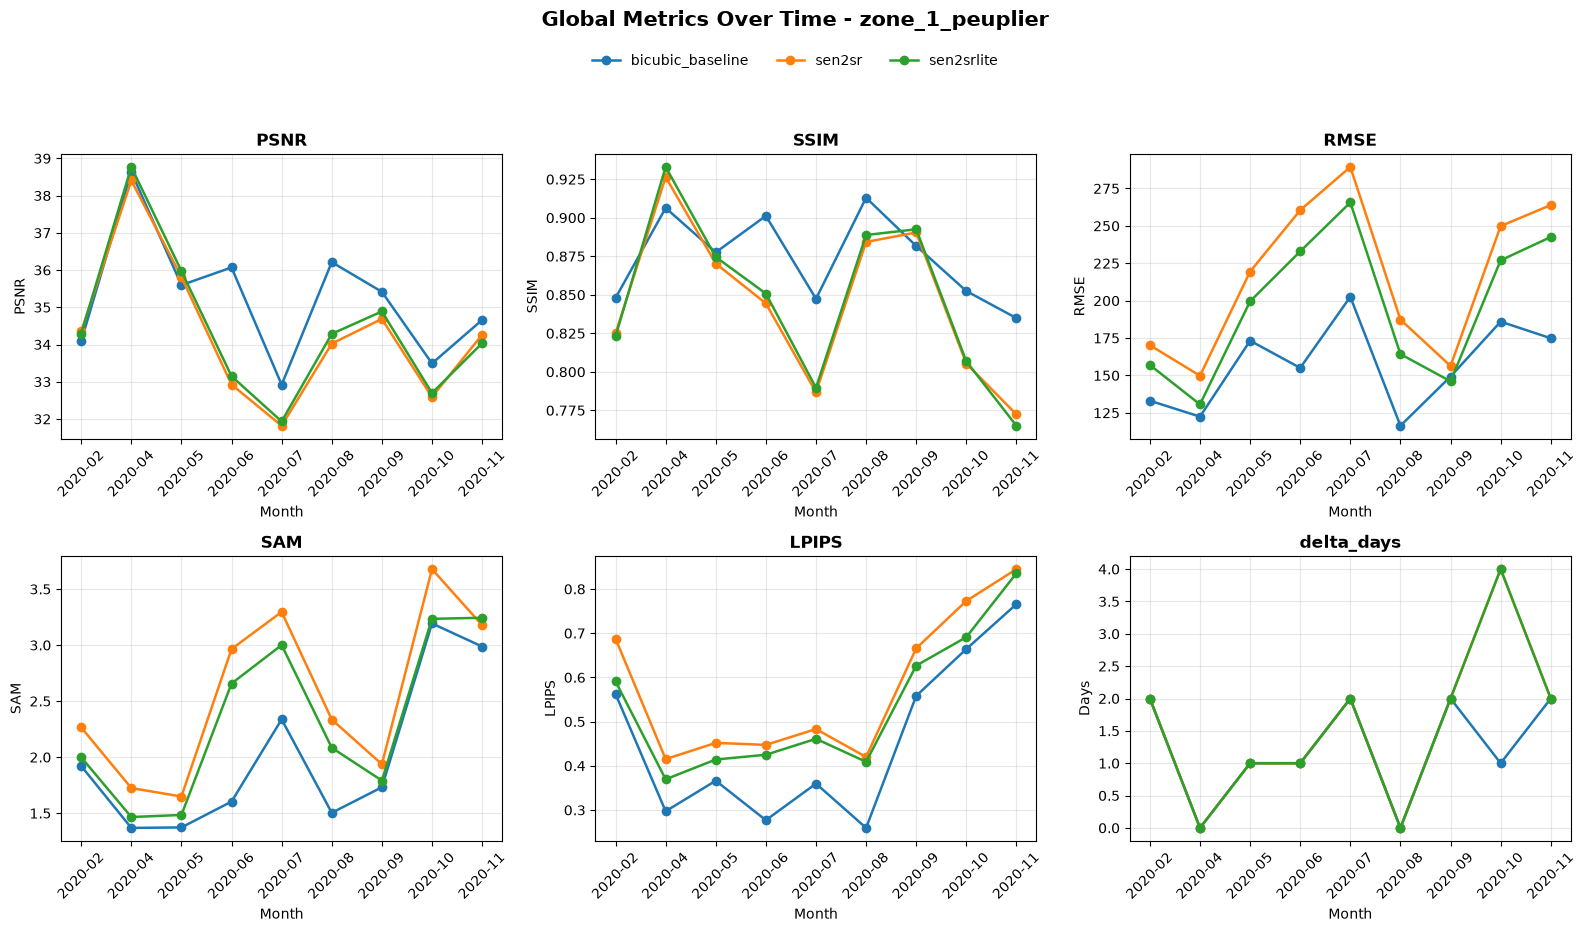

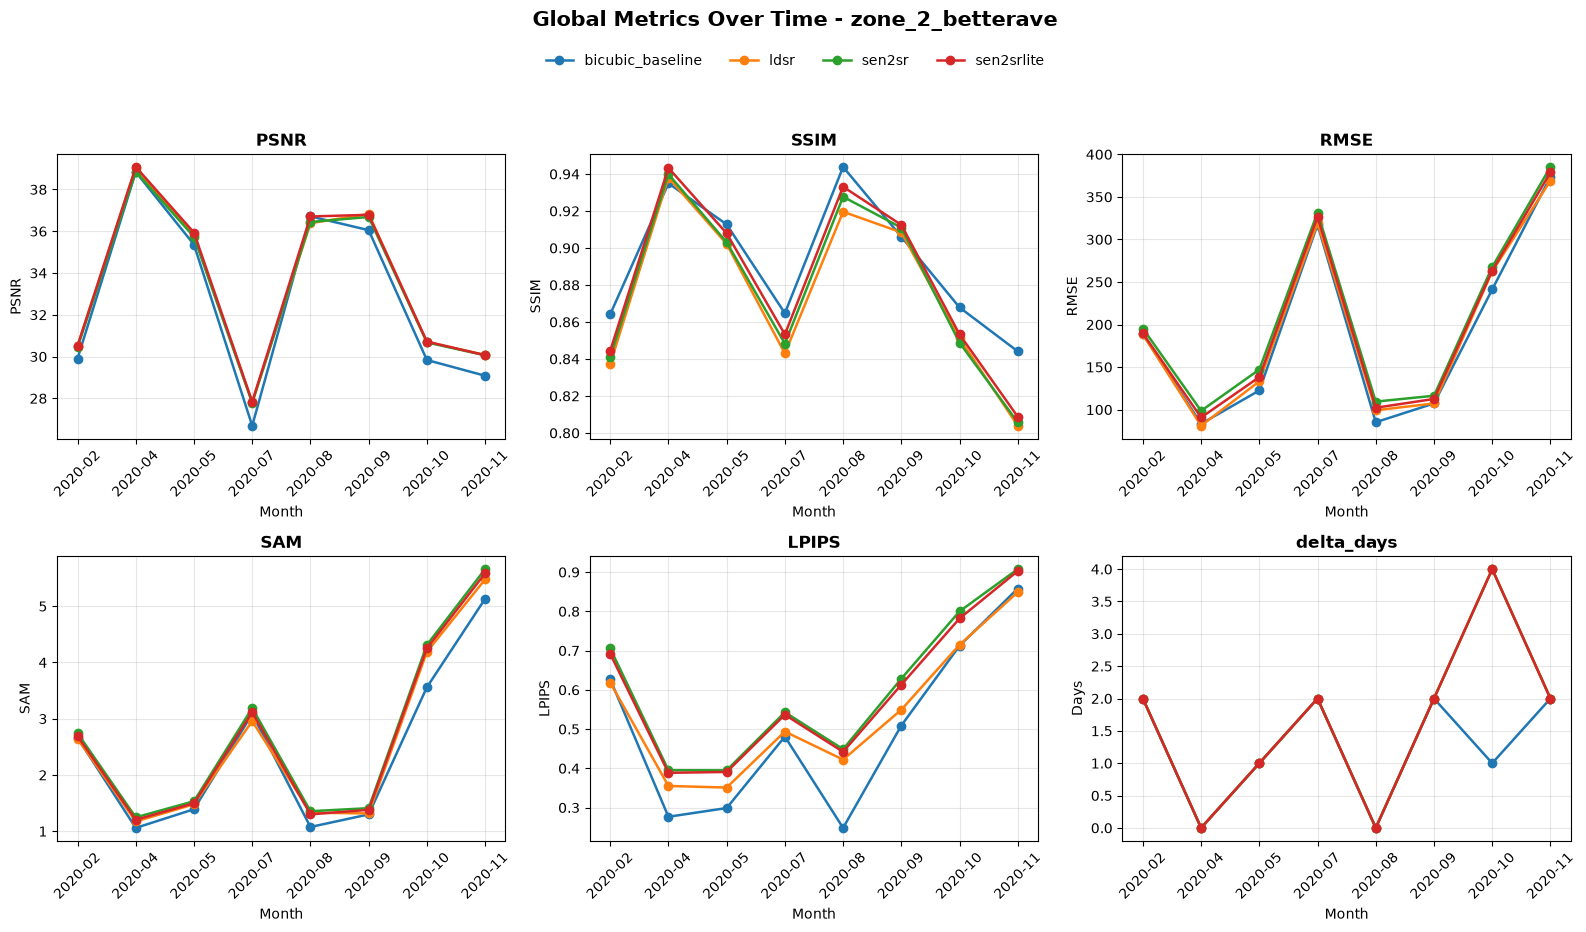

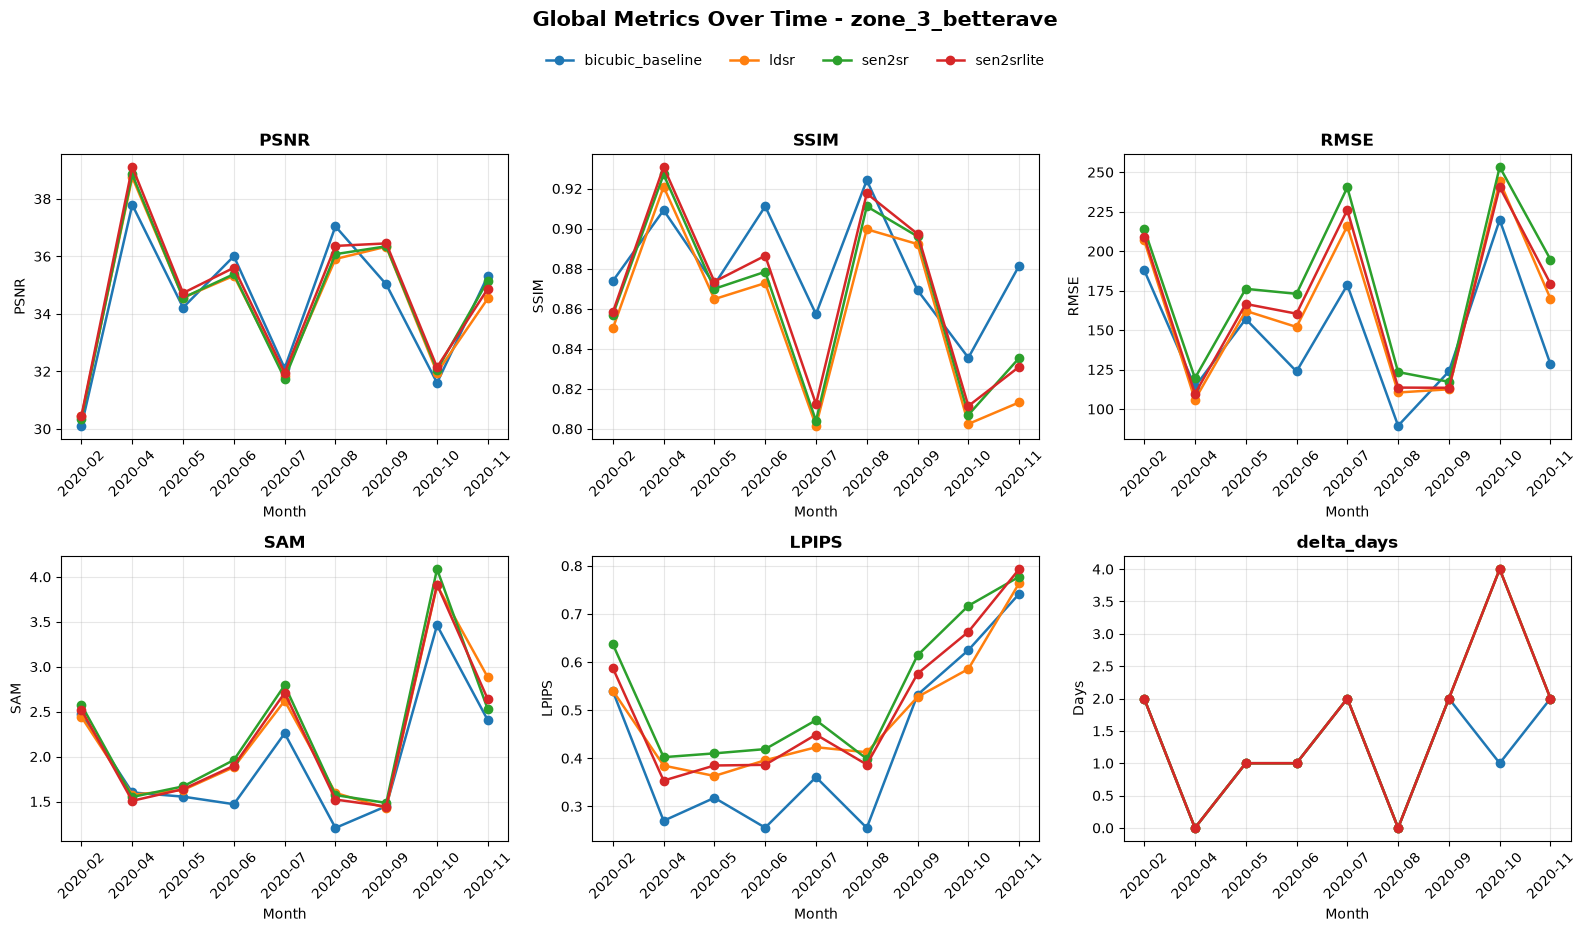

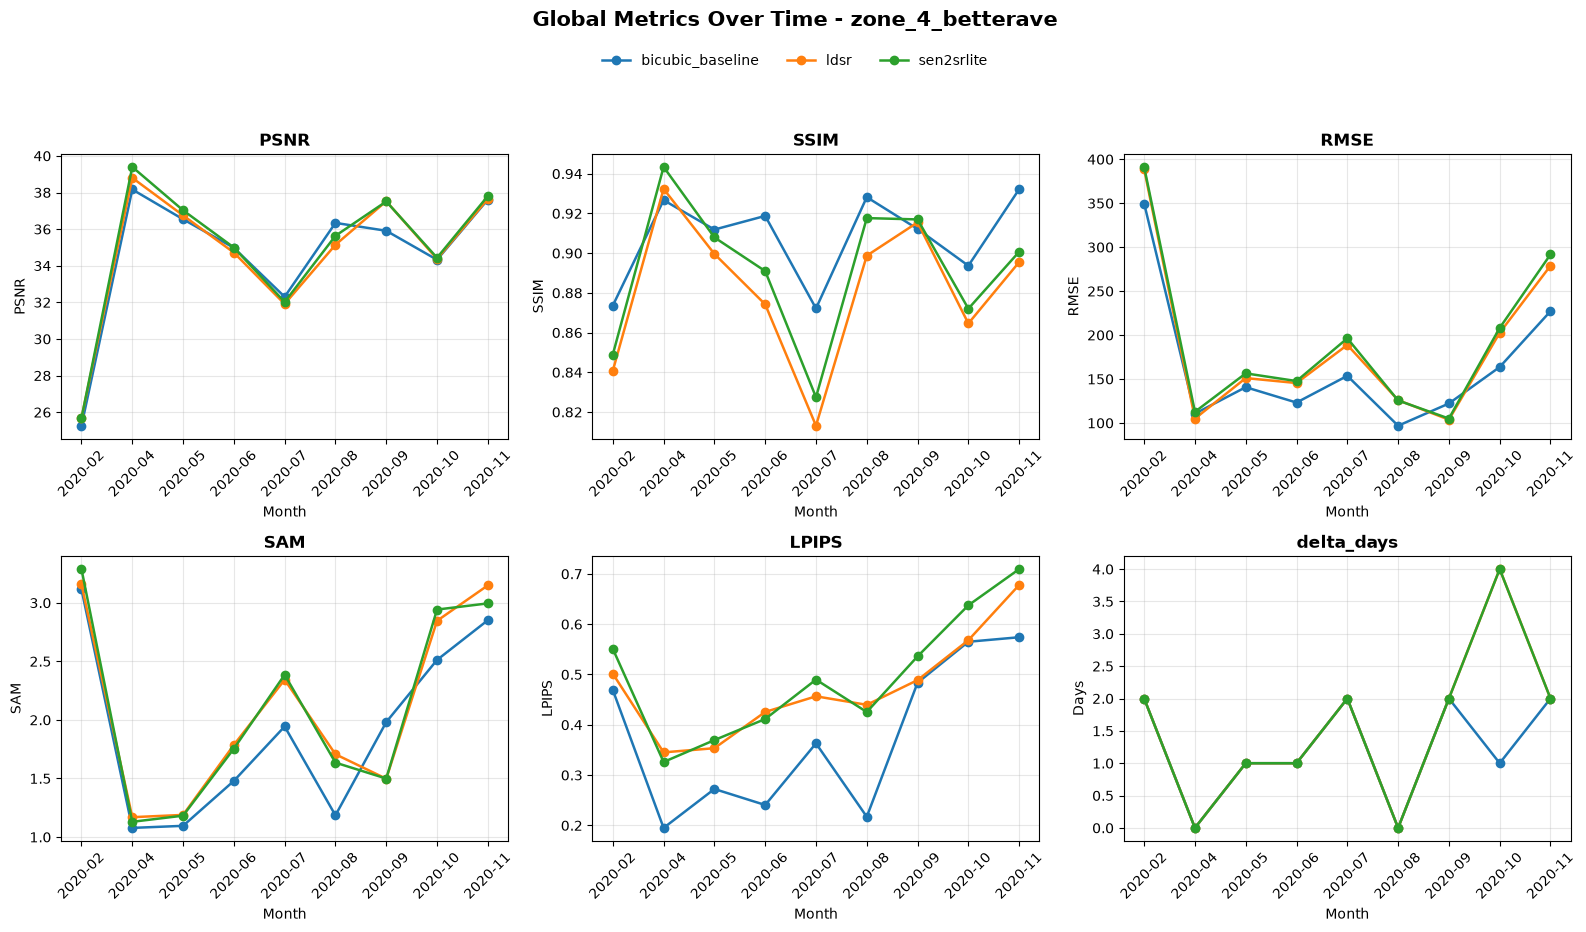

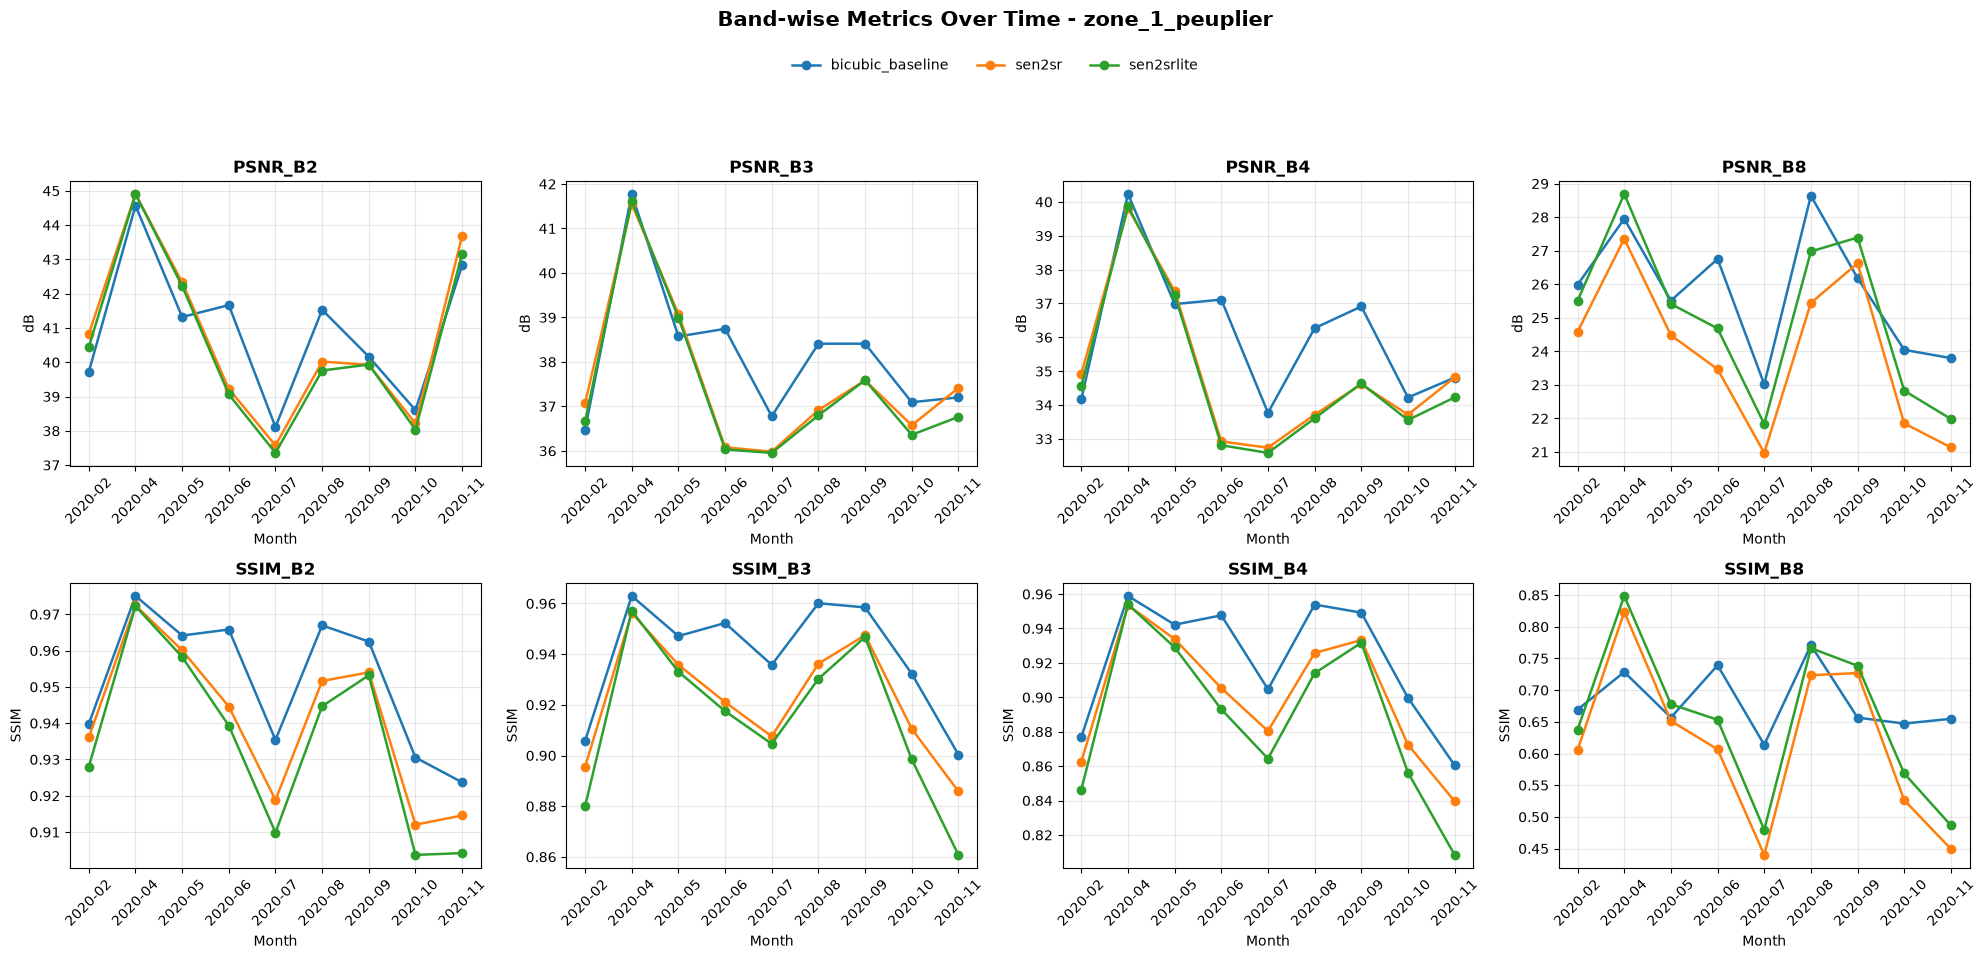

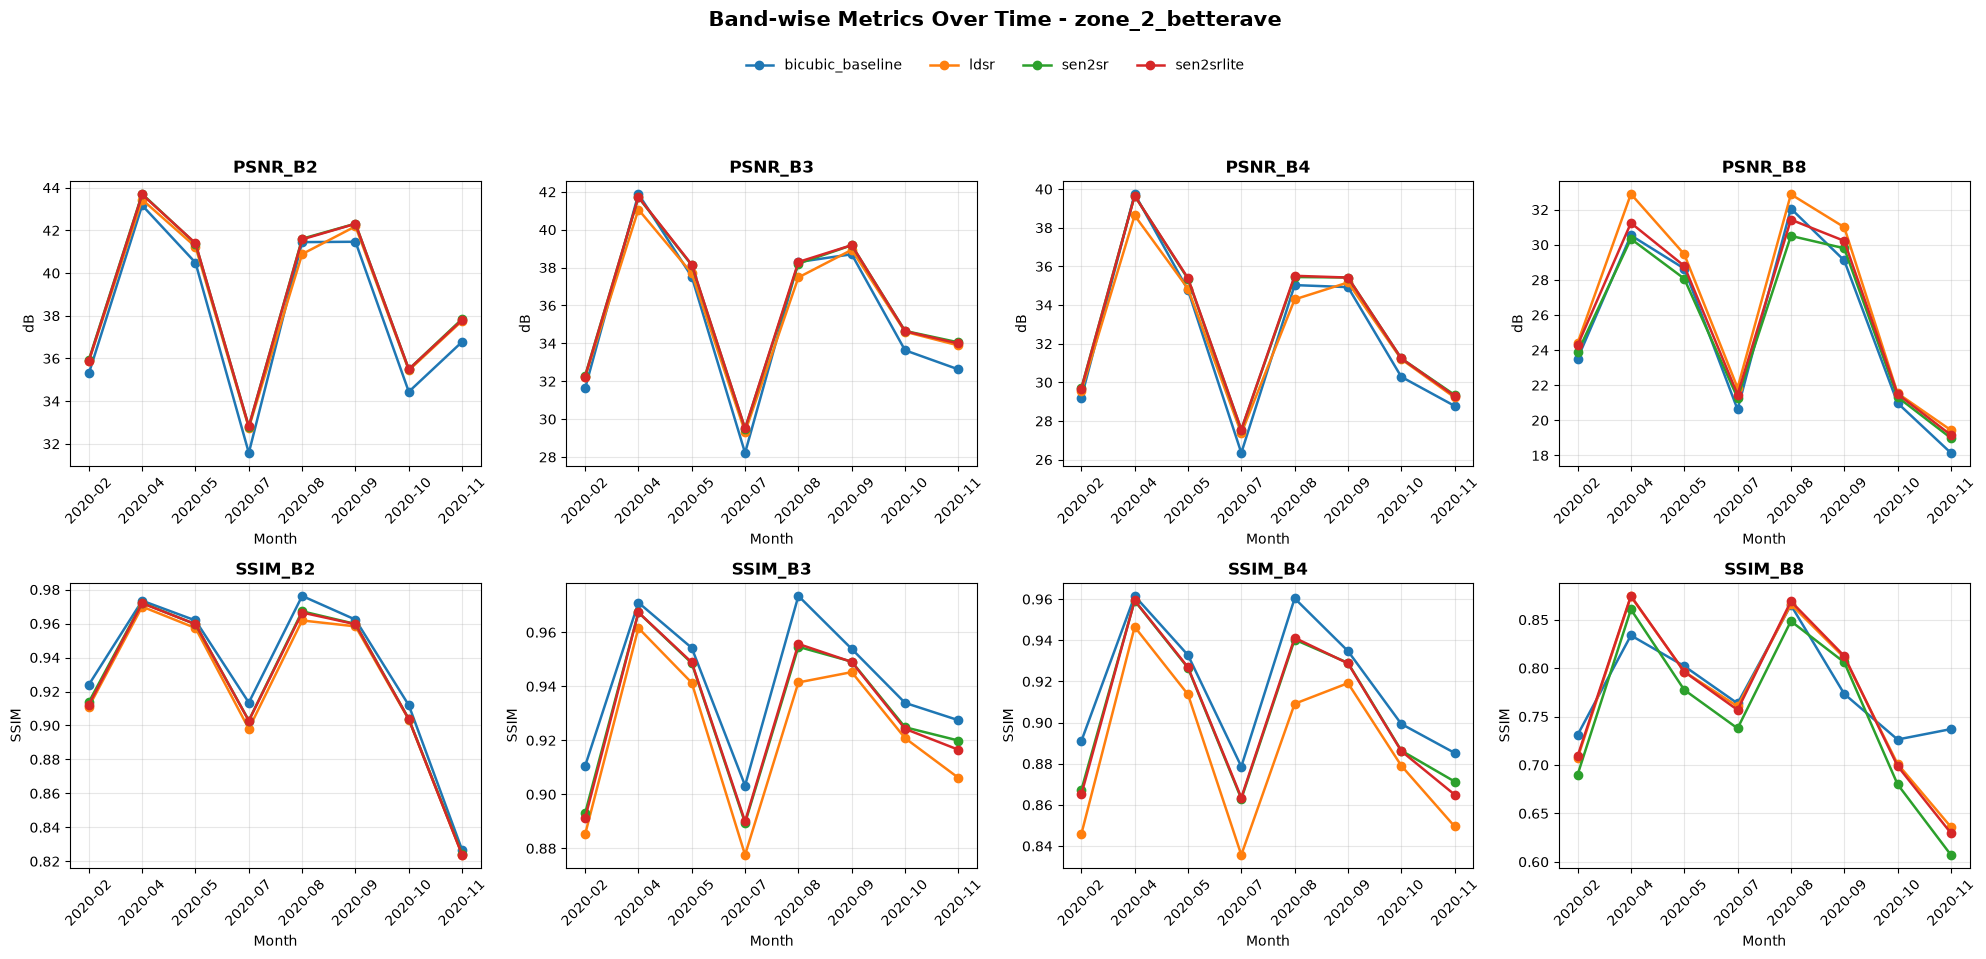

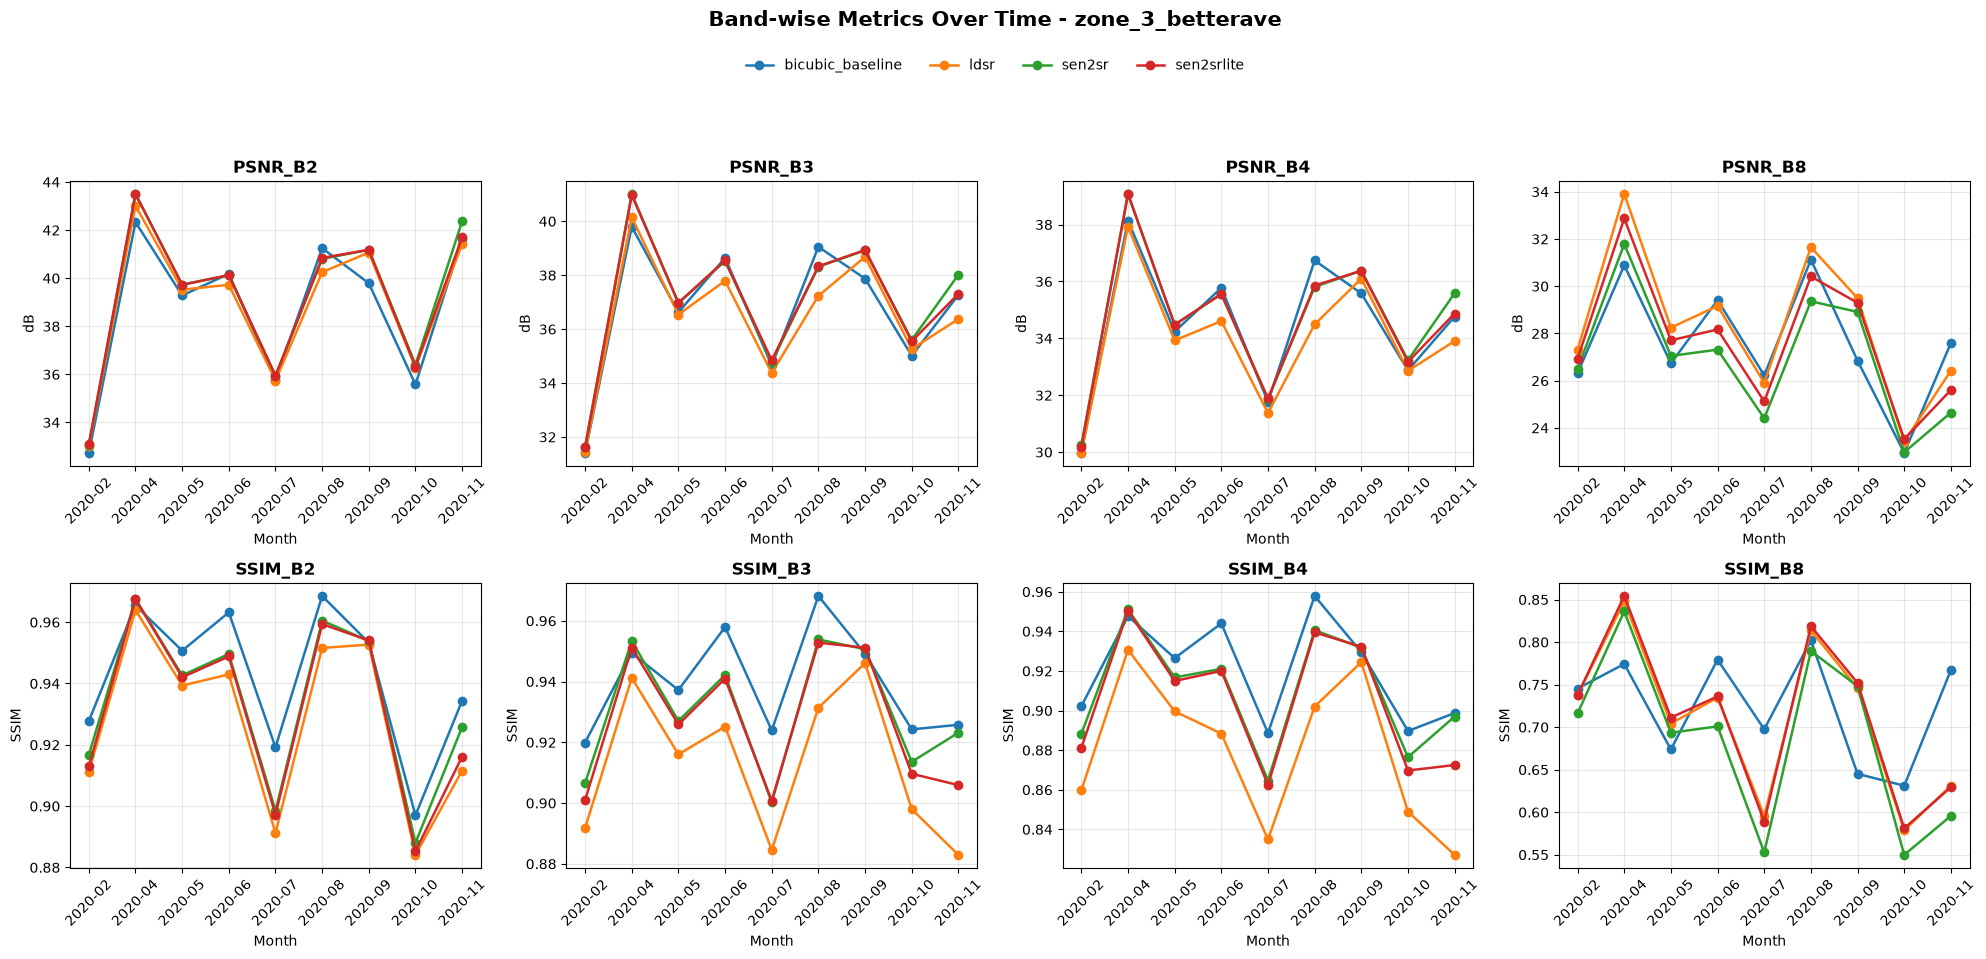

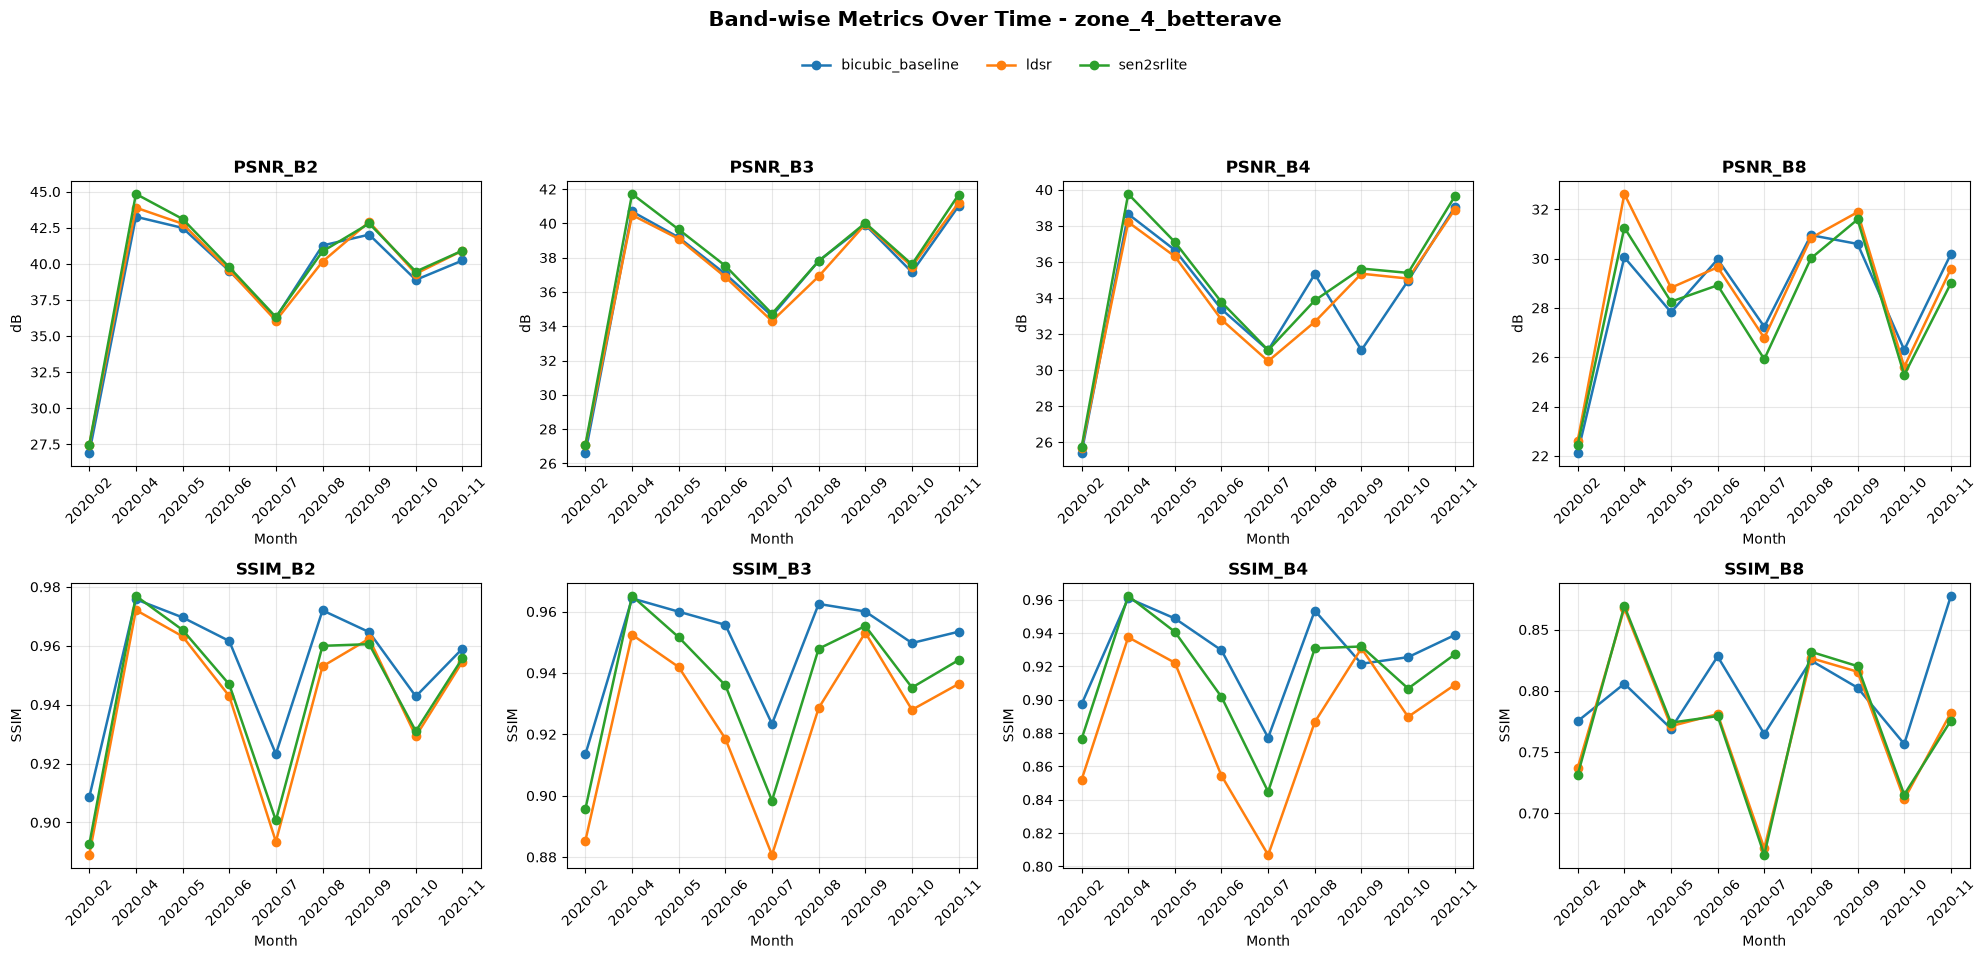


Mean metrics by zone/model:


,zone,model,PSNR,SSIM,RMSE,SAM,LPIPS,PSNR_B2,SSIM_B2,PSNR_B3,SSIM_B3,PSNR_B4,SSIM_B4,PSNR_B8,SSIM_B8,delta_days,coverage
0,zone_1_peuplier,bicubic_baseline,35.2321,0.8736,156.9806,2.0023,0.4567,40.9459,0.9515,38.1631,0.9395,36.0547,0.9215,25.7645,0.6819,1.2222,0.9871
2,zone_1_peuplier,sen2srlite,34.4468,0.8471,196.1770,2.3291,0.5359,40.5423,0.9348,37.4198,0.9143,34.7911,0.8886,25.0341,0.6508,1.5556,0.9871
1,zone_1_peuplier,sen2sr,34.3194,0.8450,216.3049,2.5588,0.5766,40.7442,0.9405,37.5835,0.9218,34.9594,0.9008,23.9904,0.6170,1.5556,0.9871
6,zone_2_betterave,sen2srlite,33.4557,0.8821,200.2458,2.6283,0.5935,38.8724,0.9250,35.9702,0.9304,32.9689,0.9045,26.0114,0.7684,1.6250,0.9791
4,zone_2_betterave,ldsr,33.3924,0.8754,194.9754,2.5709,0.5442,38.6984,0.9230,35.6542,0.9224,32.5332,0.8873,26.6836,0.7690,1.6250,0.9791
5,zone_2_betterave,sen2sr,33.3347,0.8782,206.3977,2.6812,0.6030,38.8874,0.9255,35.9652,0.9309,32.9638,0.9054,25.5226,0.7510,1.6250,0.9791
3,zone_2_betterave,bicubic_baseline,32.8093,0.8923,189.9032,2.4081,0.5014,38.0838,0.9312,35.3139,0.9410,32.3872,0.9180,25.4521,0.7791,1.2500,0.9791
10,zone_3_betterave,sen2srlite,34.6296,0.8688,168.7588,2.1988,0.5090,39.1631,0.9315,37.0100,0.9266,34.6075,0.9048,27.7380,0.7122,1.5556,0.9817
9,zone_3_betterave,sen2sr,34.5020,0.8651,179.0942,2.2462,0.5395,39.2343,0.9337,37.0873,0.9301,34.6921,0.9097,26.9944,0.6870,1.5556,0.9817
8,zone_3_betterave,ldsr,34.4058,0.8575,164.4454,2.2173,0.4886,38.8945,0.9276,36.4264,0.9130,33.9091,0.8795,28.3931,0.7100,1.5556,0.9817


In [11]:
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd

# Folder containing evaluation CSV files
RESULTS_DIR = OUTPUT_DIR

# Expected columns from your saved CSV format
required_cols = [
    "PSNR", "SSIM", "RMSE", "SAM", "LPIPS",
    "PSNR_B2", "SSIM_B2", "PSNR_B3", "SSIM_B3", "PSNR_B4", "SSIM_B4", "PSNR_B8", "SSIM_B8",
    "zone", "model", "month", "ps_date", "sr_date", "delta_days", "coverage",
]

# Load all relevant CSVs (avoid non-metrics CSVs)
csv_files = [
    p for p in sorted(RESULTS_DIR.glob("*.csv"))
    if p.name.startswith("metrics_") or p.name == "evaluation_results_all_zones.csv"
]

if not csv_files:
    raise FileNotFoundError(f"No metrics CSV files found in {RESULTS_DIR}")

frames = []
for csv_file in csv_files:
    df = pd.read_csv(csv_file)

    # Keep only files that contain the expected schema
    if not set(required_cols).issubset(df.columns):
        print(f"Skipping {csv_file.name}: missing required metric columns")
        continue

    df = df.copy()
    df["source_file"] = csv_file.name

    # Normalize time fields
    df["ps_date"] = pd.to_datetime(df["ps_date"], errors="coerce")
    df["sr_date"] = pd.to_datetime(df["sr_date"], errors="coerce")
    df["month"] = pd.to_datetime(df["month"], errors="coerce").dt.to_period("M").astype(str)

    frames.append(df)

if not frames:
    raise ValueError("No CSV with the required columns was found.")

metrics_df = pd.concat(frames, ignore_index=True)
metrics_df = metrics_df.dropna(subset=["zone", "model", "month"]).copy()

# Remove accidental duplicate rows from combining per-zone and all-zones exports
subset_cols = ["zone", "model", "month", "ps_date", "sr_date"]
metrics_df = metrics_df.drop_duplicates(subset=subset_cols)

print("Loaded rows:", len(metrics_df))
print("Zones:", sorted(metrics_df["zone"].unique()))
print("Models:", sorted(metrics_df["model"].unique()))

# ------------------------------------------------------------------
# 1) Global metrics over time (PSNR, SSIM, RMSE, SAM, LPIPS)
# ------------------------------------------------------------------
global_metrics = ["PSNR", "SSIM", "RMSE", "SAM", "LPIPS"]

for zone in sorted(metrics_df["zone"].unique()):
    zone_df = metrics_df[metrics_df["zone"] == zone]
    models = sorted(zone_df["model"].dropna().unique())

    fig, axes = plt.subplots(2, 3, figsize=(16, 9))
    axes = axes.ravel()

    for ax, metric in zip(axes, global_metrics):
        monthly = (
            zone_df.groupby(["month", "model"], as_index=False)[metric]
            .mean()
            .pivot(index="month", columns="model", values=metric)
            .sort_index()
        )

        for model in models:
            if model in monthly.columns:
                ax.plot(monthly.index, monthly[model], marker="o", linewidth=1.8, label=model)

        ax.set_title(metric, fontweight="bold")
        ax.set_xlabel("Month")
        ax.set_ylabel(metric)
        ax.grid(alpha=0.3)
        ax.tick_params(axis="x", rotation=45)

    # Use last panel for temporal diagnostics
    diag_ax = axes[-1]
    monthly_delta = (
        zone_df.groupby(["month", "model"], as_index=False)["delta_days"]
        .mean()
        .pivot(index="month", columns="model", values="delta_days")
        .sort_index()
    )
    for model in models:
        if model in monthly_delta.columns:
            diag_ax.plot(monthly_delta.index, monthly_delta[model], marker="o", linewidth=1.8, label=model)
    diag_ax.set_title("delta_days", fontweight="bold")
    diag_ax.set_xlabel("Month")
    diag_ax.set_ylabel("Days")
    diag_ax.grid(alpha=0.3)
    diag_ax.tick_params(axis="x", rotation=45)

    handles, labels = axes[0].get_legend_handles_labels()
    fig.legend(handles, labels, loc="upper center", bbox_to_anchor=(0.5, 0.995), ncol=max(1, len(labels)), frameon=False)
    fig.suptitle(f"Global Metrics Over Time - {zone}", fontsize=15, fontweight="bold", y=1.03)
    plt.tight_layout(rect=[0, 0, 1, 0.95])
    plt.show()

# ------------------------------------------------------------------
# 2) Band-wise PSNR/SSIM over time (B2, B3, B4, B8)
# ------------------------------------------------------------------
bands = ["B2", "B3", "B4", "B8"]

for zone in sorted(metrics_df["zone"].unique()):
    zone_df = metrics_df[metrics_df["zone"] == zone]
    models = sorted(zone_df["model"].dropna().unique())

    fig, axes = plt.subplots(2, 4, figsize=(20, 9), sharex=False)

    # Top row: PSNR per band
    for j, band in enumerate(bands):
        metric = f"PSNR_{band}"
        ax = axes[0, j]
        monthly = (
            zone_df.groupby(["month", "model"], as_index=False)[metric]
            .mean()
            .pivot(index="month", columns="model", values=metric)
            .sort_index()
        )
        for model in models:
            if model in monthly.columns:
                ax.plot(monthly.index, monthly[model], marker="o", linewidth=1.8, label=model)
        ax.set_title(metric, fontweight="bold")
        ax.set_xlabel("Month")
        ax.set_ylabel("dB")
        ax.grid(alpha=0.3)
        ax.tick_params(axis="x", rotation=45)

    # Bottom row: SSIM per band
    for j, band in enumerate(bands):
        metric = f"SSIM_{band}"
        ax = axes[1, j]
        monthly = (
            zone_df.groupby(["month", "model"], as_index=False)[metric]
            .mean()
            .pivot(index="month", columns="model", values=metric)
            .sort_index()
        )
        for model in models:
            if model in monthly.columns:
                ax.plot(monthly.index, monthly[model], marker="o", linewidth=1.8, label=model)
        ax.set_title(metric, fontweight="bold")
        ax.set_xlabel("Month")
        ax.set_ylabel("SSIM")
        ax.grid(alpha=0.3)
        ax.tick_params(axis="x", rotation=45)

    handles, labels = axes[0, 0].get_legend_handles_labels()
    fig.legend(handles, labels, loc="upper center", bbox_to_anchor=(0.5, 1.02), ncol=max(1, len(labels)), frameon=False)
    fig.suptitle(f"Band-wise Metrics Over Time - {zone}", fontsize=15, fontweight="bold", y=1.06)
    plt.tight_layout(rect=[0, 0, 1, 0.95])
    plt.show()

# ------------------------------------------------------------------
# 3) Compact model ranking table (mean per zone/model)
# ------------------------------------------------------------------
summary_cols = [
    "PSNR", "SSIM", "RMSE", "SAM", "LPIPS",
    "PSNR_B2", "SSIM_B2", "PSNR_B3", "SSIM_B3", "PSNR_B4", "SSIM_B4", "PSNR_B8", "SSIM_B8",
    "delta_days", "coverage",
]

summary_df = (
    metrics_df.groupby(["zone", "model"], as_index=False)[summary_cols]
    .mean()
    .sort_values(["zone", "PSNR"], ascending=[True, False])
)

print("\nMean metrics by zone/model:")
display(summary_df.round(4))